# Antispiegel — Cleaning, EDA, and BERTopic Run

Outlet-specific notebook for **Antispiegel**. Loads the raw Antispiegel exports, applies the outlet-specific cleaning rules (boilerplate removal, deduplication, length filter), runs descriptive EDA on the cleaned corpus, and fits an individual BERTopic model using the shared three-stage pipeline (SBERT → UMAP → HDBSCAN, c-TF-IDF representation) from `../01_BERTopic_configuration/`. The saved model and topic table feed the merge step in `../../02_TopicModeling/`.

In [1]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Antispiegel"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
pd.reset_option('display.max_colwidth')
df.head()


Loaded 914 rows from 307 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Antispiegel


,Date,Title,Summary,Text,Comments,URL,Full_Text,source,source_file
0,2025-04-10,Was das Krisenbarometer Gold über Trumps Zoll-...,Die Goldpreise brechen Rekorde und derzeit ver...,Zeichen auf Sturm\nWas das Krisenbarometer Gol...,Egal Anders sagt:\n10. April 2025 um 11:21 Uhr...,https://anti-spiegel.ru/2025/was-das-krisenbar...,Was das Krisenbarometer Gold über Trumps Zoll-...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
1,2025-04-10,"Hat die LGBT-Propaganda nur den Zweck, einen g...",Ich bin auf einen sehr interessanten Artikel g...,"Achtung, Verschwörungstheorie!\nHat die LGBT-P...",TonyOdessa sagt:\n10. April 2025 um 07:11 Uhr\...,https://anti-spiegel.ru/2025/hat-die-lgbt-prop...,"Hat die LGBT-Propaganda nur den Zweck, einen g...",Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
2,2025-04-10,Will die EU Krieg oder Frieden?,"Die große Frage ist derzeit nicht nur, ob die ...",Ukraine\nWill die EU Krieg oder Frieden?\nDie ...,Grobmotoriker sagt:\n10. April 2025 um 05:31 U...,https://anti-spiegel.ru/2025/will-die-eu-krieg...,Will die EU Krieg oder Frieden? Die große Frag...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
3,2025-04-11,Sind die Russen zu dumm für Propaganda?,"Diese Woche habe ich einen Artikel über die ""W...",Freitagsgedanken\nSind die Russen zu dumm für ...,VladTepes sagt:\n11. April 2025 um 19:04 Uhr\n...,https://anti-spiegel.ru/2025/sind-die-russen-z...,Sind die Russen zu dumm für Propaganda? Diese ...,Antispiegel,antispiegel_tagesartikel_2025-04-12.csv
4,2025-04-11,Mit welchem Trick Paris und London Europa in e...,London und Paris haben anscheinend einen Weg g...,Ukraine-Krieg\nMit welchem Trick Paris und Lon...,TonyOdessa sagt:\n11. April 2025 um 15:40 Uhr\...,https://anti-spiegel.ru/2025/mit-welchem-trick...,Mit welchem Trick Paris und London Europa in e...,Antispiegel,antispiegel_tagesartikel_2025-04-12.csv


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         914 non-null    object
 1   Title        914 non-null    object
 2   Summary      913 non-null    object
 3   Text         914 non-null    object
 4   Comments     236 non-null    object
 5   URL          914 non-null    object
 6   Full_Text    914 non-null    object
 7   source       914 non-null    str   
 8   source_file  914 non-null    str   
dtypes: object(7), str(2)
memory usage: 64.4+ KB


In [3]:
df = df.drop(columns=['Full_Text', 'Comments'])
df.head(1)

,Date,Title,Summary,Text,URL,source,source_file
0,2025-04-10,Was das Krisenbarometer Gold über Trumps Zoll-...,Die Goldpreise brechen Rekorde und derzeit ver...,Zeichen auf Sturm\nWas das Krisenbarometer Gol...,https://anti-spiegel.ru/2025/was-das-krisenbar...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv


Cut off comments at the end and title etc. at the beginning

In [4]:

df['Text'] = df['Text'].str.split('Teile diesen Beitrag').str[0].str.strip()

In [5]:
df['Text'].str.len().mean()

10024.2647702407

In [6]:
import re

def clean_text(text):
    if pd.isna(text):
        return text
    # Match date pattern followed by time ending with "Uhr" at the start of the article
    # Pattern: day. month year time Uhr (e.g., "10. Februar 2026 20:36 Uhr")
    pattern = r'^.*?\d{1,2}\.\s+\w+\s+\d{4}\s+\d{1,2}:\d{2}\s+Uhr\s*'
    cleaned = re.sub(pattern, '', text, count=1, flags=re.DOTALL)
    return cleaned.strip()

df['Text'] = df['Text'].apply(clean_text)
df.head(2)

,Date,Title,Summary,Text,URL,source,source_file
0,2025-04-10,Was das Krisenbarometer Gold über Trumps Zoll-...,Die Goldpreise brechen Rekorde und derzeit ver...,Die Finanzmärkte gehen gerade durch eine Krise...,https://anti-spiegel.ru/2025/was-das-krisenbar...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
1,2025-04-10,"Hat die LGBT-Propaganda nur den Zweck, einen g...",Ich bin auf einen sehr interessanten Artikel g...,Ich bin am Mittwoch auf einen Artikel von Dagm...,https://anti-spiegel.ru/2025/hat-die-lgbt-prop...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv


In [7]:
# check length to verify how much was on average deleted at the beginning
df['Text'].str.len().mean()

9669.411378555798

In [8]:
df['Text'] = df['Text'].str.replace('\n', ' ', regex=False)
df.head(2)

,Date,Title,Summary,Text,URL,source,source_file
0,2025-04-10,Was das Krisenbarometer Gold über Trumps Zoll-...,Die Goldpreise brechen Rekorde und derzeit ver...,Die Finanzmärkte gehen gerade durch eine Krise...,https://anti-spiegel.ru/2025/was-das-krisenbar...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
1,2025-04-10,"Hat die LGBT-Propaganda nur den Zweck, einen g...",Ich bin auf einen sehr interessanten Artikel g...,Ich bin am Mittwoch auf einen Artikel von Dagm...,https://anti-spiegel.ru/2025/hat-die-lgbt-prop...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv


Date

In [9]:
# Extract relevant time 
df_clean = df.copy()

start, end = "2025-08-01", "2026-01-31"

dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

df_clean = df_clean.loc[mask].copy()
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()

Rows in selected period: 613


,Date,Title,Summary,Text,URL,source,source_file
269,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...,"Der Streit um das NABU hat gezeigt, dass der W...",Der Streit um das Nationale Anti-Korruptionsbü...,https://anti-spiegel.ru/2025/bereitet-der-west...,Antispiegel,antispiegel_tagesartikel_2025-08-02.csv
270,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...,Die New York Times berichtet über ein Schreibe...,Die New York Times versucht seit langem vor Ge...,https://anti-spiegel.ru/2025/eu-kommission-hat...,Antispiegel,antispiegel_tagesartikel_2025-08-02.csv
271,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...,Die Chefin der moldawischen Wahlkommission hat...,Ende September stehen in Moldawien Parlamentsw...,https://anti-spiegel.ru/2025/wahlkommission-re...,Antispiegel,antispiegel_tagesartikel_2025-08-02.csv
272,2025-08-02,Fordert Russland wirklich die Vernichtung alle...,"Die Überschrift des RIA-Artikels ""Niemand darf...",Ich bin auf die Geschichte zuerst bei RT-DE ge...,https://anti-spiegel.ru/2025/fordert-russland-...,Antispiegel,antispiegel_tagesartikel_2025-08-03.csv
273,2025-08-02,Der Spiegel macht mal wieder Berichterstattung...,"Es ist immer wieder erstaunlich, mit welcher V...","Wer auch nicht-westliche Medien liest, der ist...",https://anti-spiegel.ru/2025/der-spiegel-macht...,Antispiegel,antispiegel_tagesartikel_2025-08-03.csv


In [10]:
df_clean['Date'].min()

Timestamp('2025-08-01 00:00:00')

In [11]:
df_clean['Date'].max()

Timestamp('2026-01-31 00:00:00')

In [12]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 613 entries, 269 to 881
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         613 non-null    datetime64[us]
 1   Title        613 non-null    object        
 2   Summary      612 non-null    object        
 3   Text         613 non-null    str           
 4   URL          613 non-null    object        
 5   source       613 non-null    str           
 6   source_file  613 non-null    str           
dtypes: datetime64[us](1), object(3), str(3)
memory usage: 33.7+ KB


Check duplicates

In [13]:
# Check duplicates by URL
url_duplicates = df_clean[df_clean.duplicated(subset=['URL'], keep=False)]
print(f"Duplicate URLs: {len(url_duplicates)} rows ({url_duplicates['URL'].nunique()} unique URLs)")

# Check duplicates by Title
title_duplicates = df_clean[df_clean.duplicated(subset=['Title'], keep=False)]
print(f"Duplicate Titles: {len(title_duplicates)} rows ({title_duplicates['Title'].nunique()} unique Titles)")

# Check duplicates by Text
text_duplicates = df_clean[df_clean.duplicated(subset=['Text'], keep=False)]
print(f"Duplicate Text: {len(text_duplicates)} rows")

# Show duplicate URLs if any
if len(url_duplicates) > 0:
    print("\n--- Sample Duplicate URLs ---")
    print(url_duplicates[['Date', 'Title', 'URL']].head(10))

Duplicate URLs: 0 rows (0 unique URLs)
Duplicate Titles: 0 rows (0 unique Titles)
Duplicate Text: 0 rows


In [14]:
# Remove articles where Title contains "Tacheles #" as this is podcast advertismenet
df_clean = df_clean[~df_clean["Title"].str.contains("Tacheles #", na=False)]
print(f"Rows after removing 'Tacheles #' articles: {len(df_clean):,}")

Rows after removing 'Tacheles #' articles: 589


Recurring podcast announcement pages surfaced in the exploratory BERTopic run. The inspection below documents those documents before they are excluded from the final modeling corpus.


In [15]:
# Inspect and remove the recurring Anti-Spiegel podcast announcement pages that surfaced in the exploratory BERTopic run.
as_podcast_announcement_mask = (
    df_clean["Text"].fillna("").str.contains(r"Anti-Spiegel-Podcast", case=False, regex=True)
    | df_clean["Text"].fillna("").str.contains(r"Den Podcast k[oö]nnen Sie hier", case=False, regex=True)
    | (
        df_clean["Text"].fillna("").str.contains(r"spotify", case=False, regex=True)
        & df_clean["Text"].fillna("").str.contains(r"\bVK\b|Netzwerk VK|russischen VK", case=False, regex=True)
    )
)

antispiegel_podcast_announcement_docs = df_clean.loc[
    as_podcast_announcement_mask,
    ["Date", "Title", "URL", "Text"],
].copy()
antispiegel_podcast_announcement_docs["removal_reason"] = "podcast_spotify_vk_announcement"
antispiegel_podcast_announcement_docs["TextExcerpt"] = (
    antispiegel_podcast_announcement_docs["Text"].fillna("").str.slice(0, 400)
)

print(f"Podcast announcement pages identified for exclusion: {len(antispiegel_podcast_announcement_docs):,}")
display(
    antispiegel_podcast_announcement_docs[["Date", "Title", "URL", "TextExcerpt", "removal_reason"]]
)

df_clean = df_clean.loc[~as_podcast_announcement_mask].copy()
print(f"Rows after removing podcast announcement pages: {len(df_clean):,}")


Podcast announcement pages identified for exclusion: 24


,Date,Title,URL,TextExcerpt,removal_reason
276,2025-08-02,Eine geopolitische Weltreise,https://anti-spiegel.ru/2025/eine-geopolitisch...,Dieses Mal haben wir beim Anti-Spiegel-Podcast...,podcast_spotify_vk_announcement
289,2025-08-08,Nächste Woche wird es spannend,https://anti-spiegel.ru/2025/naechste-woche-wi...,Das beherrschende Thema dieses Anti-Spiegel-Po...,podcast_spotify_vk_announcement
327,2025-08-23,Die 7 Zwerge aus Europa bei Trump,https://anti-spiegel.ru/2025/die-7-zwerge-aus-...,Natürlich war das Treffen von Trump mit Selens...,podcast_spotify_vk_announcement
348,2025-08-29,Deutschland geht für die Ukraine vor die Hunde,https://anti-spiegel.ru/2025/deutschland-geht-...,Diese Mal hatten wir beim Anti-Spiegel-Podcast...,podcast_spotify_vk_announcement
395,2025-09-08,"Warum gelingt es in Russland, dass Christen un...",https://anti-spiegel.ru/2025/warum-gelingt-es-...,"Nachdem Tacheles wöchentlich erscheint, haben ...",podcast_spotify_vk_announcement
423,2025-09-15,Drohnen über Polen und Reaktionen auf Kommenta...,https://anti-spiegel.ru/2025/drohnen-ueber-pol...,Da der Anti-Spiegel-Podcast nun aus zwei Theme...,podcast_spotify_vk_announcement
452,2025-09-22,Gibt es in Russland eigentlich eine Opposition?,https://anti-spiegel.ru/2025/gibt-es-in-russla...,Im politischen Teil des Podcasts ging es diese...,podcast_spotify_vk_announcement
476,2025-09-29,Manipulierte Wahlen in Moldawien und Antworten...,https://anti-spiegel.ru/2025/manipulierte-wahl...,Diese Woche ist der Anti-Spiegel-Podcast ein M...,podcast_spotify_vk_announcement
500,2025-10-06,Wie ist das Gesundheitssystem in Russland?,https://anti-spiegel.ru/2025/wie-ist-das-gesun...,Diese Folge des Anti-Spiegel-Podcasts beginnen...,podcast_spotify_vk_announcement
522,2025-10-13,Trump ohne Friedensnobelpreis und das Bildungs...,https://anti-spiegel.ru/2025/trump-ohne-friede...,Wie immer ging es im ersten Teil des Anti-Spie...,podcast_spotify_vk_announcement


Rows after removing podcast announcement pages: 565


In [16]:
antispiegel_clean = df_clean.copy()
antispiegel_clean = antispiegel_clean[['Date', 'Title', 'Text', 'source']].copy()
antispiegel_clean.to_csv("antispiegel_clean.csv", index=False, encoding="utf-8")

## EDA

In [17]:
# Create a table showing number of articles per month
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
articles_per_month = df_clean.groupby(df_clean['Date'].dt.to_period('M')).size().reset_index(name='article_count')
articles_per_month.columns = ['month', 'article_count']
articles_per_month

,month,article_count
0,2025-08,86
1,2025-09,114
2,2025-10,104
3,2025-11,77
4,2025-12,105
5,2026-01,79


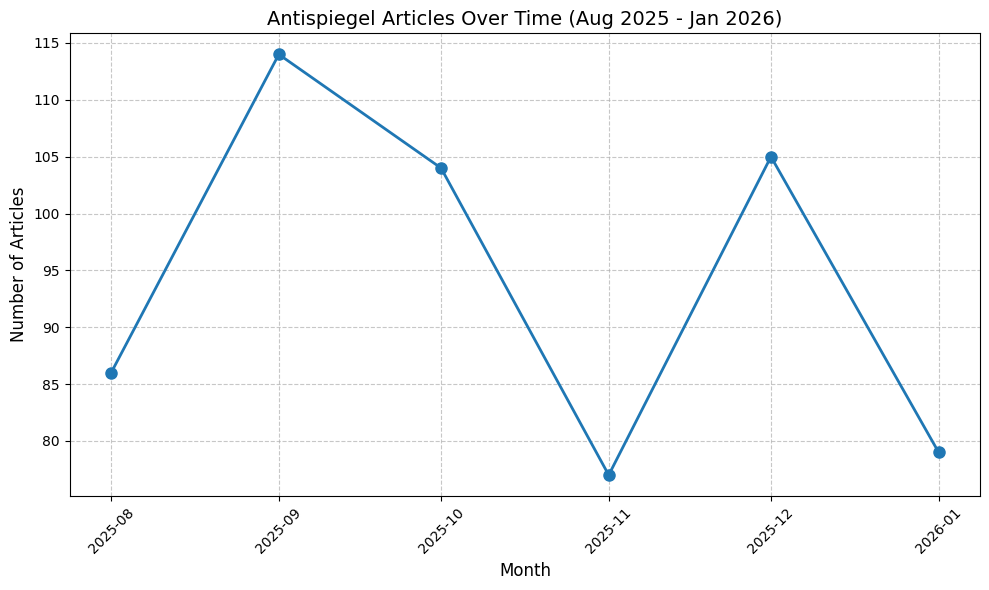

In [18]:
import matplotlib.pyplot as plt

# Create a time series plot of articles per month
fig, ax = plt.subplots(figsize=(10, 6))

# Convert period to timestamp for plotting
articles_per_month['month_ts'] = articles_per_month['month'].dt.to_timestamp()

ax.plot(articles_per_month['month_ts'], articles_per_month['article_count'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Antispiegel Articles Over Time (Aug 2025 - Jan 2026)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

eda_df["Text"] = eda_df["Text"].astype("string")
eda_df = eda_df.dropna(subset=["Date", "Text"]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 565


In [20]:
eda_df["article_length_words"] = eda_df["Text"].str.split().str.len()
eda_df["article_length_chars"] = eda_df["Text"].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count     565.0
mean     1445.8
std       793.0
min        62.0
10%       555.8
25%       948.0
50%      1363.0
75%      1838.0
90%      2286.0
95%      2867.4
99%      3975.2
max      6766.0
Name: article_length_words, dtype: float64

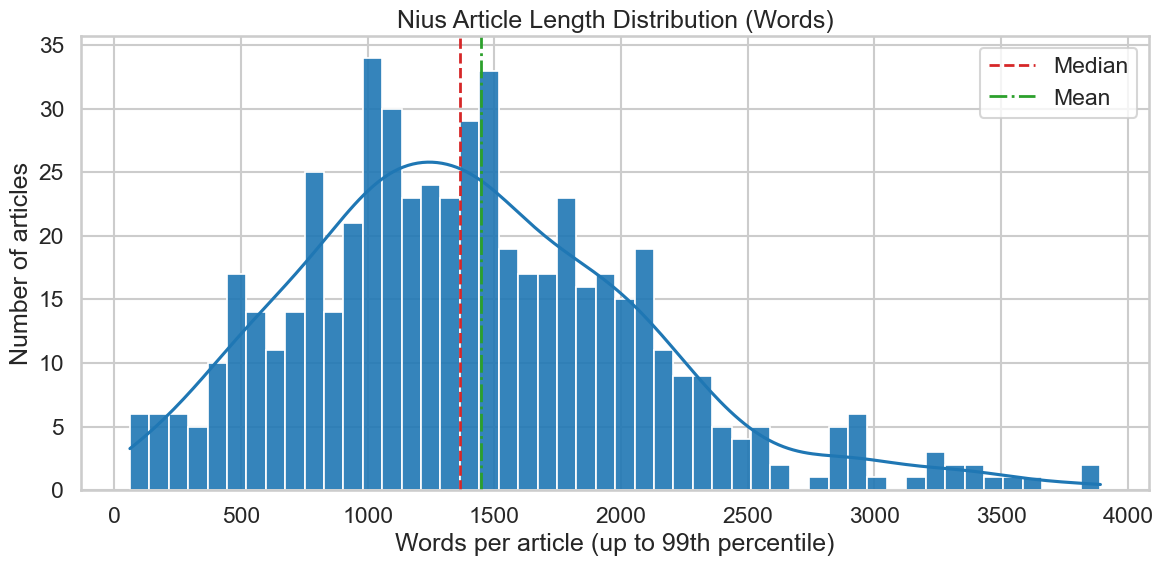

In [21]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Nius Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# Filter articles with low word count (first bar in histogram, approximately 0-100 words)
low_word_articles = eda_df[eda_df["article_length_words"] <= 200]

print(f"Number of articles with <= 100 words: {len(low_word_articles)}")
low_word_articles[["Date", "Title", "Text", "article_length_words"]].sort_values("article_length_words")

Number of articles with <= 100 words: 11


,Date,Title,Text,article_length_words
649,2025-11-17,Interview mit dem sächsischen AfD-Chef Jörg Urban,Der Fraktionsvorsitzenden der AfD im sächsisch...,62
462,2025-09-25,Interview mit den Anwälten von Thomas Röper un...,Markus Fiedler hat für apolut ein Interview mi...,79
509,2025-10-11,Ein weiteres Interview über mein neues Buch,Da ich aufgrund der politischen Verfolgung in ...,93
297,2025-08-10,Warum eine Mutter und deutsche Abgeordnete nac...,Dieses Interview finde ich aus sehr vielen Grü...,102
446,2025-09-21,Das erste Interview über mein neues Buch zur F...,Vor einigen Wochen ist mein neues Buch darüber...,102
671,2025-11-26,Zwei Tage Geburtstagpause auf dem Anti-Spiegel,"Ich habe schon geschrieben, dass es auf dem An...",133
321,2025-08-22,"Meine Anwälte erklären, wie wir uns gegen die ...",Da NuoViso diese Woche sein Sommerfest feiert ...,153
334,2025-08-26,Die Bank hat das Spendenkonto für den Rechtsst...,"Die Anwälte argumentieren, dass die Möglichkei...",154
543,2025-10-19,Der Bericht eines OSZE-Wahlbeobachters über di...,"Über die Parlamentswahlen, die vor drei Wochen...",158
664,2025-11-22,Selensky spricht von der „sehr schwierigen Ent...,Der ukrainische Machthaber Selensky hat sich a...,165


Even with a peak of articles containing a low number of words, it was decided to leave those short articles in as after manual check they seem to meaningfully contribute to the overall dataset in terms of discussed topics etc.

## BERTopic

In [23]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "02_TopicModeling").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 02_TopicModeling")

project_root = resolve_project_root()
module_root = project_root / "02_TopicModeling"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

In [24]:
from bertopic_pipeline import run_bertopic_pipeline

In [25]:
from bertopic_config import BERTopicConfig, title_config
from bertopic_pipeline import run_bertopic_pipeline


In [26]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "02_TopicModeling").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 02_TopicModeling")

PROJECT_ROOT = resolve_project_root()
MODULE_ROOT = PROJECT_ROOT / "02_TopicModeling"
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)
print("bertopic module root added:", MODULE_ROOT)

cwd: /Users/MattisHaumann/Dev/Thesis/01_EDAperOutlet
project root added: /Users/MattisHaumann/Dev/Thesis
bertopic module root added: /Users/MattisHaumann/Dev/Thesis/02_TopicModeling


In [27]:
from pathlib import Path
import sys
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CANONICAL_COMBINED_PATH = PROJECT_ROOT / "01_EDAperOutlet" / "df_combined.csv"
df_combined = pd.read_csv(CANONICAL_COMBINED_PATH)
df_clean = (
    df_combined.loc[df_combined["source"].eq("Antispiegel")]
    .copy()
    .reset_index(drop=True)
)
print(f"Loaded canonical Antispiegel subset from df_combined: {len(df_clean):,} rows")


Loaded canonical Antispiegel subset from df_combined: 565 rows


In [29]:
# Legacy baseline run kept for reference only.
# Disabled on purpose so the notebook has one canonical Antispiegel fit below.
# result_as= run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Text",
#     config=BERTopicConfig(),
#     id_col="row_id",
#     source_name="Antispiegel",
# )


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 21:02:15,379 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

2026-03-31 21:02:20,143 - BERTopic - Embedding - Completed ✓
2026-03-31 21:02:20,150 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 21:02:28,195 - BERTopic - Dimensionality - Completed ✓
2026-03-31 21:02:28,196 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 21:02:28,210 - BERTopic - Cluster - Completed ✓
2026-03-31 21:02:28,212 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 21:02:29,093 - BERTopic - Representation - Completed ✓


In [ ]:
print("Legacy Antispiegel preview disabled. Use the canonical `result_as` / `result` preview cells below.")


In [31]:
# Canonical final Antispiegel run.
# The parameters tuned/played around with here were `hdbscan_min_cluster_size`,
# `hdbscan_min_samples`, `min_df`, `max_df`, `umap_n_neighbors`, and `umap_min_dist`.
# Final choice: a moderately coarser full-text setup so Anti-Spiegel is less fragmented
# and more comparable for the later merged BERTopic.
result_as = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(
        hdbscan_min_cluster_size=12,  # slightly coarser than before to avoid micro-topics
        hdbscan_min_samples=2,        # default 10 -> fewer docs pushed to -1
        min_df=2,                     # drop very rare terms that can splinter small topics
        max_df=0.95,                  # avoid over-pruning frequent terms
        umap_n_neighbors=15,          # a bit more global structure for topic stability
        umap_min_dist=0.05,           # slight separation between clusters
        nr_topics=None,               # do not force topic reduction
    ),
    id_col="row_id",
    source_name="Antispiegel",
)


# Keep downstream notebook cells unchanged (they use `result`)
result = result_as


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 21:02:35,508 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

2026-03-31 21:02:42,043 - BERTopic - Embedding - Completed ✓
2026-03-31 21:02:42,046 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 21:02:45,813 - BERTopic - Dimensionality - Completed ✓
2026-03-31 21:02:45,816 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 21:02:45,860 - BERTopic - Cluster - Completed ✓
2026-03-31 21:02:45,872 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 21:02:52,076 - BERTopic - Representation - Completed ✓


In [32]:
topic_info = result_as["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,73,-1_spiegel_kirk_nato_charlie,"[spiegel, kirk, nato, charlie, türkei, bip, br...",[Der Spiegel sieht sich als Verteidiger all de...
1,0,47,0_trumps_demokraten_venezuela_washington,"[trumps, demokraten, venezuela, washington, tr...",[Die politische Woche in den USA war ausgespro...
2,1,41,1_selensky_nabu_ukrainischen_selenskys,"[selensky, nabu, ukrainischen, selenskys, korr...",[Der Korruptionsskandal in der Ukraine wird vo...
3,2,32,2_vermögenswerte_belgien_euro_kommission,"[vermögenswerte, belgien, euro, kommission, ge...",[Vor dem gestrigen EU-Gipfel habe ich berichte...
4,3,28,3_merz_macron_deutsche_koalition,"[merz, macron, deutsche, koalition, euro, verm...",[Und wieder war der Bericht des Deutschland-Ko...
5,4,24,4_raketen_burevestnik_poseidon_rakete,"[raketen, burevestnik, poseidon, rakete, reich...",[In den 80er Jahren sorgte der NATO-Doppelbesc...
6,5,24,5_selensky_europäer_plan_treffen,"[selensky, europäer, plan, treffen, trumps, si...","[Axios hat am Mittwoch gemeldet, die US-Regier..."
7,6,23,6_polen_ukrainer_ukrainischen_polnische,"[polen, ukrainer, ukrainischen, polnische, pol...",[Aus aktuellem Anlass veröffentliche ich hier ...
8,7,22,7_fernen_treffen_fernen osten_osten,"[fernen, treffen, fernen osten, osten, möchte,...",[Die Ergebnisse des fünfstündigen Gespräche zw...
9,8,21,8_gaza_israel_hamas_netanjahu,"[gaza, israel, hamas, netanjahu, israelische, ...",[Natürlich war der Angriff der Hamas auf Israe...


### Outlier Reduction (focused section)

This section starts from the already fitted Antispiegel topic model (`result_as`) and keeps the reduction workflow compact.

The recurring Anti-Spiegel podcast announcement pages identified in the exploratory run are filtered in the cleaning section before BERTopic fitting, so the reduced model below already uses the refiltered corpus.

> **Final downstream workflow:** use the canonical final Antispiegel fit above, then apply `reduce_outliers(..., strategy="c-tf-idf", threshold=0.10)`.


In [33]:
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_as).
base_result = result_as
topic_model_base = base_result["topic_model"]
docs_as = list(base_result["docs"])
topics_as = list(base_result["topics"])
prepared_docs = base_result["prepared_documents"].copy()
baseline_topic_ids = {topic for topic in topics_as if topic != -1}

new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
    docs_as,
    topics_as,
    strategy="c-tf-idf",
    threshold=0.10,
)
new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
representation_same = deepcopy(topic_model_base.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs_as,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
    top_n_words=topic_model_base.top_n_words,
)
topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_as_reduced = dict(base_result)
result_as_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_as_reduced["topic_model"] = topic_model_ctfidf_threshold
result_as_reduced["topic_info"] = topic_info_ctfidf_threshold
result_as_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_as_reduced["doc_info"] = doc_info_reduced
result_as_reduced["display_topic_map"] = display_topic_map
result_as_reduced["display_label_map"] = display_label_map

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_as) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": "ctfidf_threshold_0.10",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(redistributed_topic_ids),
    },
])
display(summary_final)
display(topic_info_ctfidf_threshold.head(20))

2026-03-31 21:03:01,993 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count,Non_Outlier_Topic_Count
0,baseline,73,30
1,ctfidf_threshold_0.10,37,30


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_thailand_akw_britischen_spiegel,-1,37,-1_thailand_akw_britischen_spiegel,"[thailand, akw, britischen, spiegel, nepal, tü...",[Der Spiegel sieht sich als Verteidiger all de...
1,0,1,Topic 1 — trumps_demokraten_venezuela_amerikan...,trumps_demokraten_venezuela_amerikanischen,0,54,0_trumps_demokraten_venezuela_amerikanischen,"[trumps, demokraten, venezuela, amerikanischen...",[Die politische Woche in den USA war ausgespro...
2,1,2,Topic 2 — selensky_nabu_ukrainischen_selenskys,selensky_nabu_ukrainischen_selenskys,1,43,1_selensky_nabu_ukrainischen_selenskys,"[selensky, nabu, ukrainischen, selenskys, korr...",[Der Korruptionsskandal in der Ukraine wird vo...
3,2,3,Topic 3 — vermögenswerte_belgien_euro_kommission,vermögenswerte_belgien_euro_kommission,2,35,2_vermögenswerte_belgien_euro_kommission,"[vermögenswerte, belgien, euro, kommission, ru...",[Vor dem gestrigen EU-Gipfel habe ich berichte...
4,3,4,Topic 4 — deutsche_merz_macron_euro,deutsche_merz_macron_euro,3,31,3_deutsche_merz_macron_euro,"[deutsche, merz, macron, euro, koalition, afd,...",[Und wieder war der Bericht des Deutschland-Ko...
5,4,6,Topic 6 — raketen_burevestnik_poseidon_rakete,raketen_burevestnik_poseidon_rakete,4,26,4_raketen_burevestnik_poseidon_rakete,"[raketen, burevestnik, poseidon, rakete, reich...",[In den 80er Jahren sorgte der NATO-Doppelbesc...
6,5,7,Topic 7 — selensky_europäer_treffen_plan,selensky_europäer_treffen_plan,5,26,5_selensky_europäer_treffen_plan,"[selensky, europäer, treffen, plan, trumps, si...","[Axios hat am Mittwoch gemeldet, die US-Regier..."
7,6,5,Topic 5 — polen_ukrainischen_ukrainer_polnische,polen_ukrainischen_ukrainer_polnische,6,27,6_polen_ukrainischen_ukrainer_polnische,"[polen, ukrainischen, ukrainer, polnische, nor...",[Aus aktuellem Anlass veröffentliche ich hier ...
8,7,9,Topic 9 — fernen_treffen_fernen osten_osten,fernen_treffen_fernen osten_osten,7,22,7_fernen_treffen_fernen osten_osten,"[fernen, treffen, fernen osten, osten, möchte,...",[Die Ergebnisse des fünfstündigen Gespräche zw...
9,8,8,Topic 8 — israel_gaza_netanjahu_hamas,israel_gaza_netanjahu_hamas,8,23,8_israel_gaza_netanjahu_hamas,"[israel, gaza, netanjahu, hamas, israelische, ...",[Natürlich war der Angriff der Hamas auf Israe...


### Save final reduced model (`as_model` overwrite)

Persist the final threshold-based reduced model so this is the canonical saved Antispiegel model in `02_TopicModeling/outputs/as_model` for downstream loading and merged-model use.


In [34]:
from pathlib import Path
import shutil

# Keep a reusable reduced result dict in notebook memory and save the canonical final Antispiegel model to outputs/.
result_as = result_as_reduced
result = result_as
topic_info = result_as["topic_info"]
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")

project_root = find_project_root(Path.cwd())
save_dir = project_root / "02_TopicModeling" / "outputs" / "as_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

print(f"Saved final reduced model to: {save_dir}")

Saved final reduced model to: /Users/MattisHaumann/Dev/Thesis/02_TopicModeling/outputs/as_model


In [35]:
# Unified display numbering for the final reduced model (largest topic = Topic 1).
topic_display_result = result_as_reduced if "result_as_reduced" in globals() else result_as
topic_info = topic_display_result["topic_info"].copy()
display_topic_map = topic_display_result["display_topic_map"]
display_label_map = topic_display_result["display_label_map"]

display(topic_info.head(20))

,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_thailand_akw_britischen_spiegel,-1,37,-1_thailand_akw_britischen_spiegel,"[thailand, akw, britischen, spiegel, nepal, tü...",[Der Spiegel sieht sich als Verteidiger all de...
1,0,1,Topic 1 — trumps_demokraten_venezuela_amerikan...,trumps_demokraten_venezuela_amerikanischen,0,54,0_trumps_demokraten_venezuela_amerikanischen,"[trumps, demokraten, venezuela, amerikanischen...",[Die politische Woche in den USA war ausgespro...
2,1,2,Topic 2 — selensky_nabu_ukrainischen_selenskys,selensky_nabu_ukrainischen_selenskys,1,43,1_selensky_nabu_ukrainischen_selenskys,"[selensky, nabu, ukrainischen, selenskys, korr...",[Der Korruptionsskandal in der Ukraine wird vo...
3,2,3,Topic 3 — vermögenswerte_belgien_euro_kommission,vermögenswerte_belgien_euro_kommission,2,35,2_vermögenswerte_belgien_euro_kommission,"[vermögenswerte, belgien, euro, kommission, ru...",[Vor dem gestrigen EU-Gipfel habe ich berichte...
4,3,4,Topic 4 — deutsche_merz_macron_euro,deutsche_merz_macron_euro,3,31,3_deutsche_merz_macron_euro,"[deutsche, merz, macron, euro, koalition, afd,...",[Und wieder war der Bericht des Deutschland-Ko...
5,4,6,Topic 6 — raketen_burevestnik_poseidon_rakete,raketen_burevestnik_poseidon_rakete,4,26,4_raketen_burevestnik_poseidon_rakete,"[raketen, burevestnik, poseidon, rakete, reich...",[In den 80er Jahren sorgte der NATO-Doppelbesc...
6,5,7,Topic 7 — selensky_europäer_treffen_plan,selensky_europäer_treffen_plan,5,26,5_selensky_europäer_treffen_plan,"[selensky, europäer, treffen, plan, trumps, si...","[Axios hat am Mittwoch gemeldet, die US-Regier..."
7,6,5,Topic 5 — polen_ukrainischen_ukrainer_polnische,polen_ukrainischen_ukrainer_polnische,6,27,6_polen_ukrainischen_ukrainer_polnische,"[polen, ukrainischen, ukrainer, polnische, nor...",[Aus aktuellem Anlass veröffentliche ich hier ...
8,7,9,Topic 9 — fernen_treffen_fernen osten_osten,fernen_treffen_fernen osten_osten,7,22,7_fernen_treffen_fernen osten_osten,"[fernen, treffen, fernen osten, osten, möchte,...",[Die Ergebnisse des fünfstündigen Gespräche zw...
9,8,8,Topic 8 — israel_gaza_netanjahu_hamas,israel_gaza_netanjahu_hamas,8,23,8_israel_gaza_netanjahu_hamas,"[israel, gaza, netanjahu, hamas, israelische, ...",[Natürlich war der Angriff der Hamas auf Israe...


### UMAP topic map (reduced model, no re-fit)

Visualize the final reduced topics from the threshold workflow above.


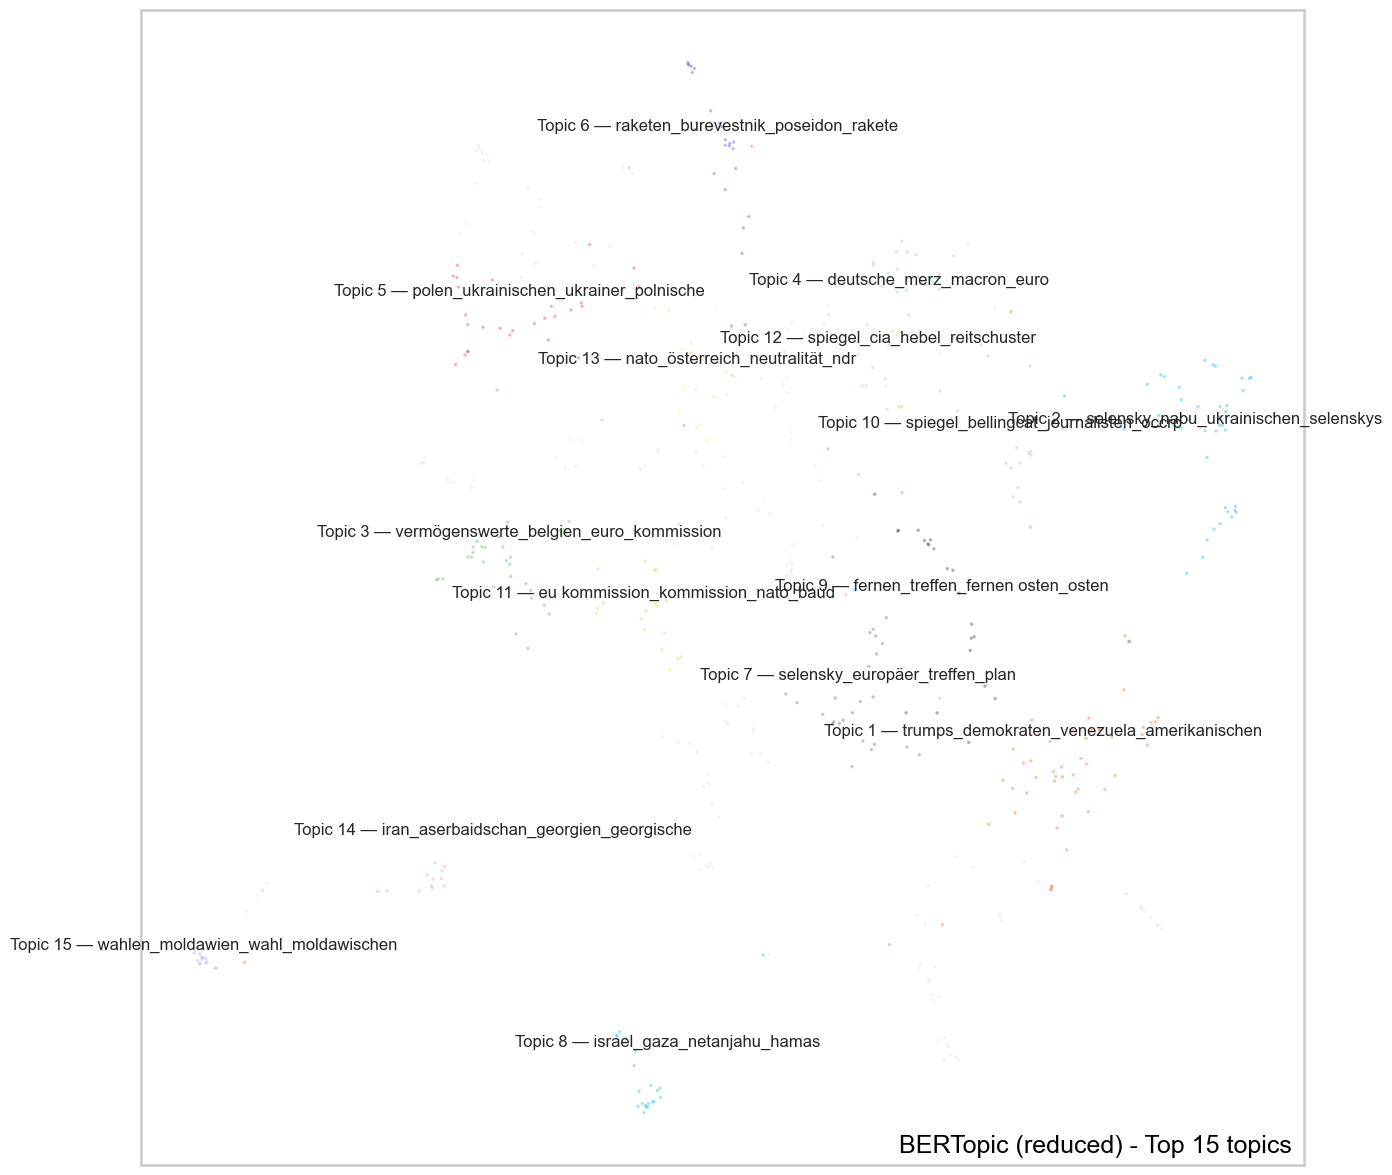

In [36]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP

run_result = result_as_reduced if "result_as_reduced" in globals() else result_as
topic_model_plot = run_result["topic_model"]
docs_plot = list(run_result["docs"])
topics_plot = list(run_result["topics"])
topic_info_plot = run_result["topic_info"].copy()
display_label_map = run_result["display_label_map"]

embeddings = topic_model_plot._extract_embeddings(docs_plot, method="document")
umap_model = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine").fit(embeddings)
df_plot = pd.DataFrame(umap_model.embedding_, columns=["x", "y"])
df_plot["topic"] = topics_plot

top_n = 15
fontsize = 12

top_topic_ids = (
    topic_info_plot.loc[topic_info_plot["Topic"] != -1]
    .nsmallest(top_n, "DisplayTopic")["Topic"]
    .tolist()
)

to_plot = df_plot.copy()
to_plot.loc[~to_plot["topic"].isin(top_topic_ids), "topic"] = -1
outliers = to_plot.loc[to_plot["topic"] == -1]
non_outliers = to_plot.loc[to_plot["topic"] != -1]

cmap = matplotlib.colors.ListedColormap([
    "#FF5722", "#03A9F4", "#4CAF50", "#80CBC4", "#673AB7",
    "#795548", "#E91E63", "#212121", "#00BCD4", "#CDDC39",
    "#AED581", "#FFE082", "#BCAAA4", "#B39DDB", "#F48FB1",
])

fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(outliers["x"], outliers["y"], c="#E0E0E0", s=1, alpha=0.3)
ax.scatter(non_outliers["x"], non_outliers["y"], c=non_outliers["topic"], s=1, alpha=0.3, cmap=cmap)

centroids = non_outliers.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic = int(row["topic"])
    label = display_label_map.get(topic, f"Topic {topic}")
    ax.text(row["x"], row["y"] * 1.01, label, fontsize=fontsize, horizontalalignment="center")

ax.text(0.99, 0.01, f"BERTopic (reduced) - Top {top_n} topics",
        transform=ax.transAxes, horizontalalignment="right", color="black")
plt.xticks([], [])
plt.yticks([], [])
plt.show()

In [ ]:
# Legacy scratch cell intentionally left blank.


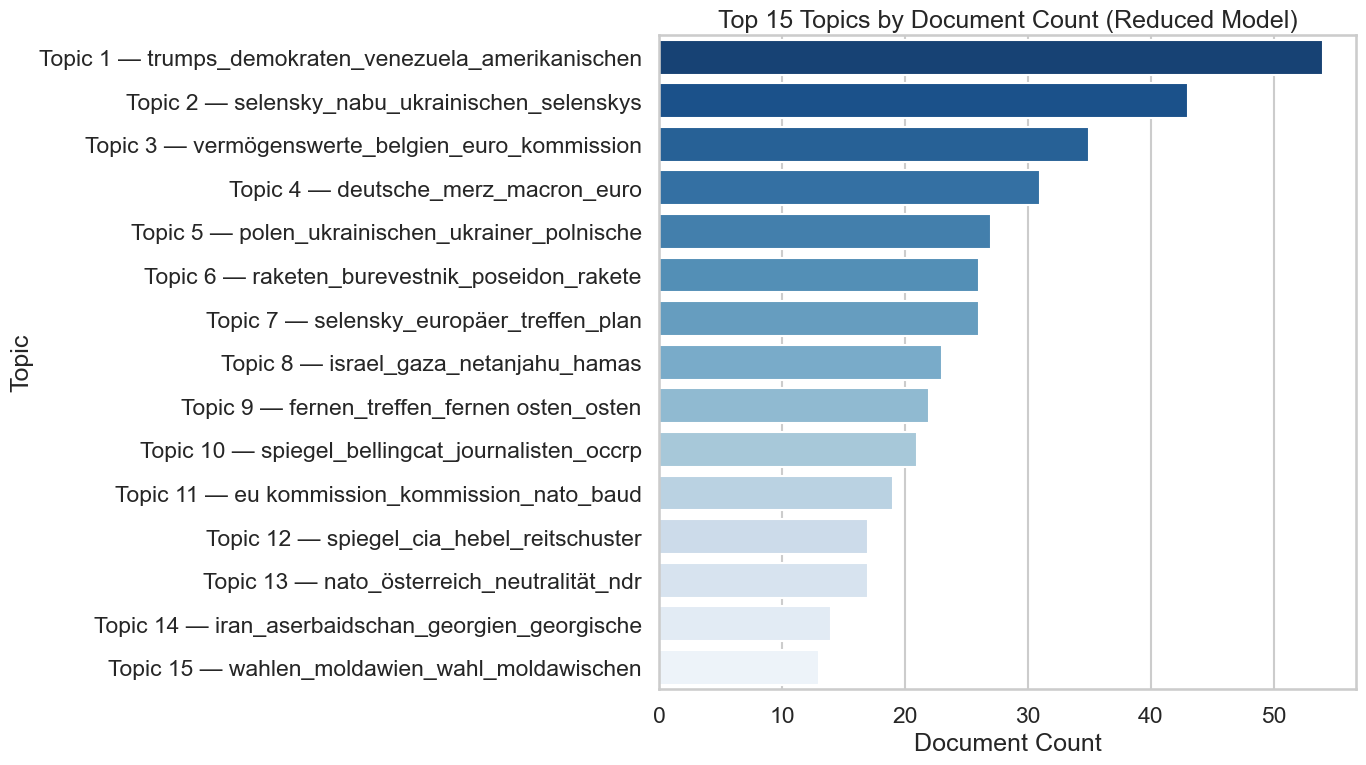

In [37]:
import seaborn as sns

# Ensure plotting libs exist in current kernel.
import matplotlib.pyplot as plt

# Re-run this cell after outlier reduction to visualize the final reduced model with unified topic numbering.
run_result = result_as_reduced if "result_as_reduced" in globals() else result_as
topic_info_run = run_result["topic_info"].copy()

if "DisplayTopic" not in topic_info_run.columns:
    topic_info_run["OriginalTopic"] = topic_info_run["Topic"]
    topic_info_run["TopicNameClean"] = topic_info_run["Name"].str.replace(r"^\d+_", "", regex=True)
    ranked_topics = (
        topic_info_run.loc[topic_info_run["Topic"] != -1, ["Topic", "Count"]]
        .sort_values(["Count", "Topic"], ascending=[False, True])
        .reset_index(drop=True)
    )
    ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
    display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))
    topic_info_run["DisplayTopic"] = topic_info_run["Topic"].map(display_topic_map).astype("Int64")
    topic_info_run["DisplayLabel"] = topic_info_run.apply(
        lambda row: "Outliers"
        if row["Topic"] == -1
        else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
        axis=1,
    )

top15_topics = (
    topic_info_run.loc[topic_info_run["Topic"] != -1]
    .nsmallest(15, "DisplayTopic")
    .sort_values("DisplayTopic")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="DisplayLabel",
    order=top15_topics["DisplayLabel"].tolist(),
    palette="Blues_r",
    ax=ax,
)

ax.set_title("Top 15 Topics by Document Count (Reduced Model)")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()

In [38]:
# Fix: ensure `result` exists for downstream cells (and ignore the stray `im` typo above)
if "result" not in globals():
    if "result_as" in globals():
        result = result_as
    elif "result_full_text" in globals():
        result = result_full_text
    else:
        raise NameError("No BERTopic result found. Run the BERTopic pipeline cell first.")

topic_info = result["topic_info"]
print(f"`result` is ready. Topics: {len(topic_info)}")
topic_info.head(5)

`result` is ready. Topics: 31


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_thailand_akw_britischen_spiegel,-1,37,-1_thailand_akw_britischen_spiegel,"[thailand, akw, britischen, spiegel, nepal, tü...",[Der Spiegel sieht sich als Verteidiger all de...
1,0,1,Topic 1 — trumps_demokraten_venezuela_amerikan...,trumps_demokraten_venezuela_amerikanischen,0,54,0_trumps_demokraten_venezuela_amerikanischen,"[trumps, demokraten, venezuela, amerikanischen...",[Die politische Woche in den USA war ausgespro...
2,1,2,Topic 2 — selensky_nabu_ukrainischen_selenskys,selensky_nabu_ukrainischen_selenskys,1,43,1_selensky_nabu_ukrainischen_selenskys,"[selensky, nabu, ukrainischen, selenskys, korr...",[Der Korruptionsskandal in der Ukraine wird vo...
3,2,3,Topic 3 — vermögenswerte_belgien_euro_kommission,vermögenswerte_belgien_euro_kommission,2,35,2_vermögenswerte_belgien_euro_kommission,"[vermögenswerte, belgien, euro, kommission, ru...",[Vor dem gestrigen EU-Gipfel habe ich berichte...
4,3,4,Topic 4 — deutsche_merz_macron_euro,deutsche_merz_macron_euro,3,31,3_deutsche_merz_macron_euro,"[deutsche, merz, macron, euro, koalition, afd,...",[Und wieder war der Bericht des Deutschland-Ko...


## OLD

In [ ]:
# Full-text config for Antispiegel topic modeling
config_full_text = BERTopicConfig(
    min_text_chars=80,
    min_tokens=12,
    min_df=2,
    max_df=0.75,
    ngram_range=(1, 3),
    umap_n_neighbors=8,
    umap_n_components=5,
    umap_min_dist=0.0,
    hdbscan_min_cluster_size=4,
    hdbscan_min_samples=2,
    extra_stopwords=(
        "für", "hat", "haben", "wird", "werden", "wurde",
        "sagte", "sagt", "sei", "sind",
        "antispiegel", "artikel", "podcast", "video", "spotify",
    ),
)

# Title-only config for Antispiegel topic modeling
config_title = title_config(
    ngram_range=(1, 2),
    hdbscan_min_cluster_size=4,
    hdbscan_min_samples=2,
    extra_stopwords=(
        "für", "hat", "haben", "wird", "werden", "wurde",
        "sagte", "sagt", "sei", "sind",
        "antispiegel", "artikel", "podcast", "video", "spotify",
    ),
)


In [ ]:
# Legacy exploratory comparison kept for reference only.
# Disabled on purpose. The canonical Antispiegel model is the tuned full-text run above.
# result_full_text = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Text",
#     config=config_full_text,
#     id_col="row_id",
#     source_name="Antispiegel",
# )
# result_title = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Title",
#     config=config_title,
#     id_col="row_id",
#     source_name="Antispiegel",
# )
# result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-03 17:11:20,790 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

2026-03-03 17:11:37,951 - BERTopic - Embedding - Completed ✓
2026-03-03 17:11:38,053 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-03 17:11:41,258 - BERTopic - Dimensionality - Completed ✓
2026-03-03 17:11:41,322 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-03 17:11:41,964 - BERTopic - Cluster - Completed ✓
2026-03-03 17:11:42,155 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-03 17:11:50,567 - BERTopic - Representation - Completed ✓


In [ ]:
print("Legacy Antispiegel preview disabled. Use the canonical `result_as` / `result` preview cells below.")


In [ ]:
doc_info = result["doc_info"]
doc_info.head()

,original_index,document_id,source_name,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,269,https://anti-spiegel.ru/2025/bereitet-der-west...,Antispiegel,Der Streit um das Nationale Anti-Korruptionsbü...,15,15_nabu_selensky_timoschenko_jermak,"[nabu, selensky, timoschenko, jermak, selensky...","[Im Sommer hat Selensky versucht, die von den ...",nabu - selensky - timoschenko - jermak - selen...,1.000000,True
1,270,https://anti-spiegel.ru/2025/eu-kommission-hat...,Antispiegel,Die New York Times versucht seit langem vor Ge...,48,48_merkel_minsker_2021_minsker abkommen,"[merkel, minsker, 2021, minsker abkommen, abko...",[Die New York Times versucht seit langem vor G...,merkel - minsker - 2021 - minsker abkommen - a...,1.000000,True
2,271,https://anti-spiegel.ru/2025/wahlkommission-re...,Antispiegel,Ende September stehen in Moldawien Parlamentsw...,4,4_wahlen_moldawien_wahl_moldawischen,"[wahlen, moldawien, wahl, moldawischen, sandu,...",[Den ersten Meldungen zufolge ist die Parlamen...,wahlen - moldawien - wahl - moldawischen - san...,1.000000,False
3,272,https://anti-spiegel.ru/2025/fordert-russland-...,Antispiegel,Ich bin auf die Geschichte zuerst bei RT-DE ge...,21,21_cia_reitschuster_modi_indien,"[cia, reitschuster, modi, indien, entwickelt, ...",[Ich bin zufällig auf einen Artikel eines russ...,cia - reitschuster - modi - indien - entwickel...,0.279494,False
4,273,https://anti-spiegel.ru/2025/der-spiegel-macht...,Antispiegel,"Wer auch nicht-westliche Medien liest, der ist...",-1,-1_spiegel_indien_euro_brics,"[spiegel, indien, euro, brics, korruption, eur...",[Über diesen Korruptionsfall hat zuerst die „Z...,spiegel - indien - euro - brics - korruption -...,0.000000,False


In [ ]:
Antispiegel_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

In [ ]:
Antispiegel_topics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           589 non-null    int64         
 1   Date            589 non-null    datetime64[ns]
 2   Title           589 non-null    object        
 3   Summary         588 non-null    object        
 4   Text            589 non-null    object        
 5   URL             589 non-null    object        
 6   source          589 non-null    object        
 7   source_file     589 non-null    object        
 8   original_index  589 non-null    int64         
 9   Topic           589 non-null    int64         
 10  Name            589 non-null    object        
 11  Probability     589 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 55.3+ KB


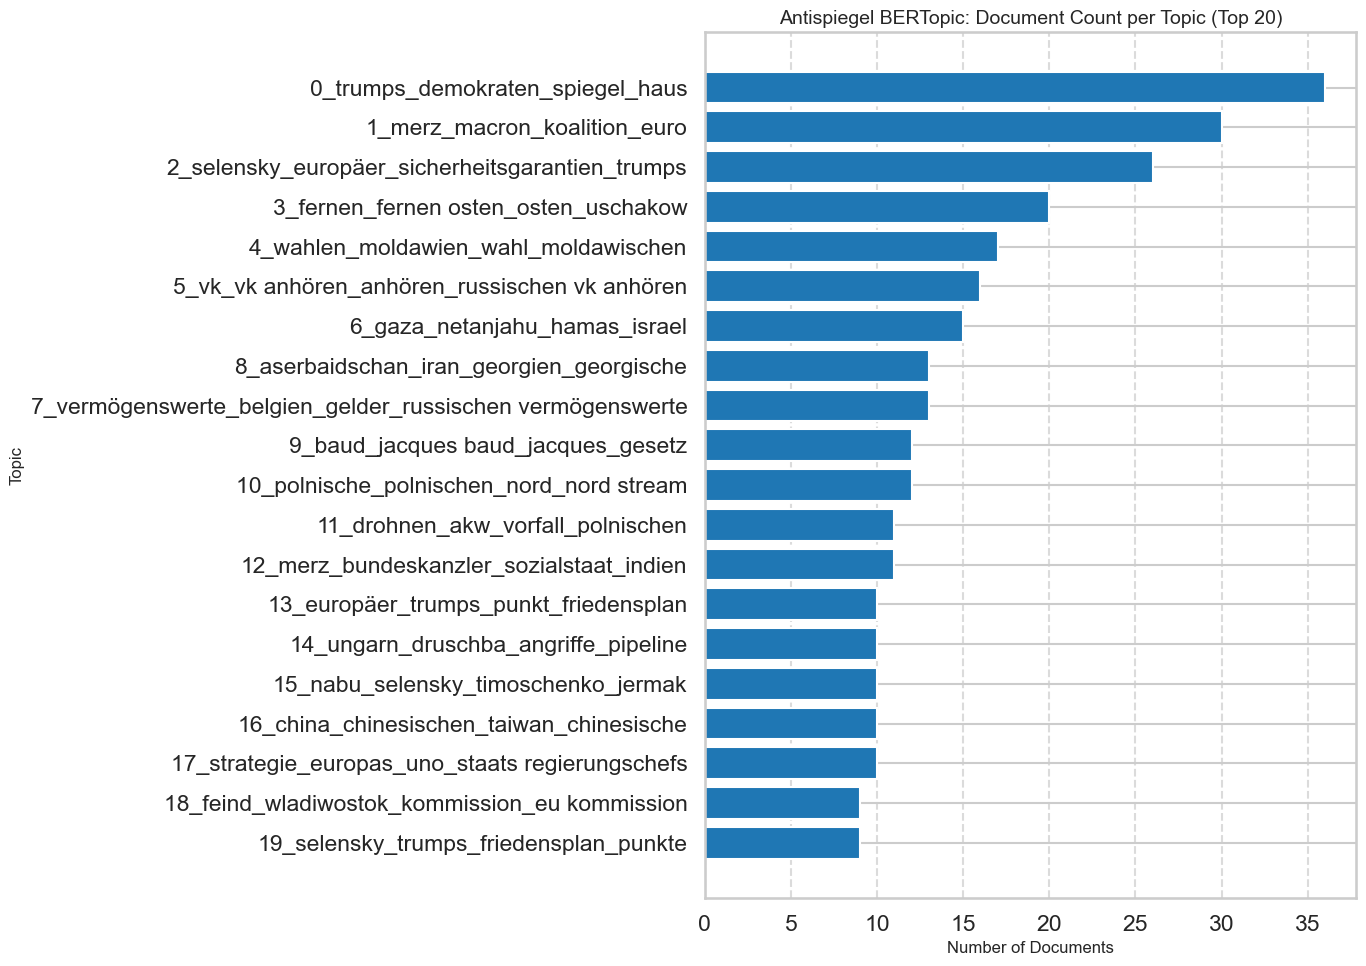

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) and get top 20 topics by count
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.nlargest(20, 'Count').sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('Antispiegel BERTopic: Document Count per Topic (Top 20)', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Prepare data for topics over time using the final reduced model if it already exists.
# Re-run this cell after outlier reduction to pick up `result_as_reduced`.
topic_time_result = result_as_reduced if "result_as_reduced" in globals() else result_as

topic_info_time = topic_time_result["topic_info"].copy()
prepared_docs_time = topic_time_result["prepared_documents"]
date_col = "Date" if "Date" in prepared_docs_time.columns else "day"
prepared_dates = pd.to_datetime(prepared_docs_time[date_col], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()

docs_for_time = [doc for doc, ok in zip(topic_time_result["docs"], valid_time_mask) if ok]
topics_for_time = [topic for topic, ok in zip(topic_time_result["topics"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = topic_time_result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    topics=topics_for_time,
    nr_bins=6,
)

topic_info_non_outliers = topic_info_time.loc[topic_info_time["Topic"] != -1].copy()
if "DisplayTopic" in topic_info_non_outliers.columns:
    top_10_topics = topic_info_non_outliers.nsmallest(10, "DisplayTopic")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["DisplayLabel"]))
else:
    top_10_topics = topic_info_non_outliers.nlargest(10, "Count")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["Name"]))

topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = label_map.get(topic, f"Topic {topic}")
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("Antispiegel: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Final BERTopic comparison table: all topics + representative words
from IPython.display import display

topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

def _representative_words_for_topic(topic_id: int) -> str:
    terms = result["topic_model"].get_topic(int(topic_id)) or []
    return ", ".join(word for word, _ in terms)

topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(topics_comparison_df)


In [ ]:
print("Experimental BERTopic v2 run removed. The saved final Antispiegel model uses the standard BERTopic pipeline above.")


In [ ]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Antispiegel"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

# Keep a dedicated Text column and normalize expected column aliases.
if "Text" not in df.columns and "article_text" in df.columns:
    df["Text"] = df["article_text"]
if "title" not in df.columns and "Title" in df.columns:
    df["title"] = df["Title"]
if "date" not in df.columns and "Date" in df.columns:
    df["date"] = df["Date"]
if "url" not in df.columns and "URL" in df.columns:
    df["url"] = df["URL"]

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")


In [ ]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "02_TopicModeling").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 02_TopicModeling")

project_root = resolve_project_root()
module_root = project_root / "02_TopicModeling"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))


In [ ]:
from bertopic_config import BERTopicConfig, title_config
from bertopic_pipeline import run_bertopic_pipeline


In [ ]:
# Prepare Antispiegel dataframe for topic modeling from canonical df_combined
CANONICAL_COMBINED_PATH = project_root / "01_EDAperOutlet" / "df_combined.csv"
df_combined = pd.read_csv(CANONICAL_COMBINED_PATH)
df_clean = (
    df_combined.loc[df_combined["source"].eq("Antispiegel")]
    .copy()
    .reset_index(drop=True)
)
df_clean["day"] = pd.to_datetime(df_clean["Date"], errors="coerce")

df_clean["Text"] = (
    df_clean["Text"]
    .astype("string")
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

df_clean["title"] = (
    df_clean["Title"]
    .astype("string")
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

print(f"Rows prepared for BERTopic: {len(df_clean):,}")
df_clean[["row_id", "title", "Text", "day"]].head()


In [ ]:
# Legacy exploratory run kept for reference only.
# Disabled on purpose. The canonical Antispiegel model is the tuned run above.
# result = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Text",
#     config=BERTopicConfig(hdbscan_min_cluster_size=25),
#     id_col="row_id",
#     source_name="Antispiegel",
# )


In [ ]:
print("Legacy Antispiegel preview disabled. Use the canonical `result_as` / `result` preview cells below.")


In [ ]:
# BERTopic quality metrics
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


metrics = evaluate_bertopic(
    docs=result["docs"],
    topic_model=result["topic_model"],
    top_k=10,
)
metrics


In [ ]:
doc_info = result["doc_info"].copy()

# Compact topic overview: number of linked documents per topic (no long text columns).
group_cols = [c for c in ["Topic", "Name"] if c in doc_info.columns]
doc_info_overview = (
    doc_info.groupby(group_cols, dropna=False)
    .size()
    .reset_index(name="Doc_Count")
    .sort_values("Doc_Count", ascending=False)
    .reset_index(drop=True)
)

if "Probability" in doc_info.columns:
    avg_prob = (
        doc_info.groupby(group_cols, dropna=False)["Probability"]
        .mean()
        .reset_index(name="Avg_Probability")
    )
    doc_info_overview = doc_info_overview.merge(avg_prob, on=group_cols, how="left")
    doc_info_overview["Avg_Probability"] = doc_info_overview["Avg_Probability"].round(3)

if "Name" in doc_info_overview.columns:
    doc_info_overview["Name"] = doc_info_overview["Name"].astype("string").str.slice(0, 60)

doc_info_overview


In [ ]:
antispiegel_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

# Compact overview display (no full article text column).
display_cols = [c for c in ["day", "title", "Topic", "Name", "Probability"] if c in antispiegel_topics.columns]
antispiegel_topics[display_cols].head()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info["Topic"] != -1].copy()
topic_counts = topic_counts.nlargest(20, "Count").sort_values("Count", ascending=True)

ax.barh(topic_counts["Name"], topic_counts["Count"], color="#1f77b4", edgecolor="white")

ax.set_xlabel("Number of Documents", fontsize=12)
ax.set_ylabel("Topic", fontsize=12)
ax.set_title("Antispiegel BERTopic: Document Count per Topic", fontsize=14)
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# Prepare data for topics over time using the final reduced model if it already exists.
# Re-run this cell after outlier reduction to pick up `result_as_reduced`.
topic_time_result = result_as_reduced if "result_as_reduced" in globals() else result_as

topic_info_time = topic_time_result["topic_info"].copy()
prepared_docs_time = topic_time_result["prepared_documents"]
date_col = "Date" if "Date" in prepared_docs_time.columns else "day"
prepared_dates = pd.to_datetime(prepared_docs_time[date_col], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()

docs_for_time = [doc for doc, ok in zip(topic_time_result["docs"], valid_time_mask) if ok]
topics_for_time = [topic for topic, ok in zip(topic_time_result["topics"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = topic_time_result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    topics=topics_for_time,
    nr_bins=6,
)

topic_info_non_outliers = topic_info_time.loc[topic_info_time["Topic"] != -1].copy()
if "DisplayTopic" in topic_info_non_outliers.columns:
    top_10_topics = topic_info_non_outliers.nsmallest(10, "DisplayTopic")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["DisplayLabel"]))
else:
    top_10_topics = topic_info_non_outliers.nlargest(10, "Count")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["Name"]))

topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = label_map.get(topic, f"Topic {topic}")
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("Antispiegel: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
